In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Load your dataset
df = pd.read_csv(r"C:\Users\SNEHALATA ROUT\Downloads\collections.natural_history_study.clinical_data.csv")
# Define target
als_labels = ["Probable Lab Supported", "Definite", "Probable", "possible"]
non_als_labels = ["N/D", "N/A", "PEN", "SUSPECTED"]

df["Target"] = df["Als Diagnosis By Revised El Escorial Criteria For Als"].apply(
    lambda x: 1 if x in als_labels else 0
)

# Select presymptomatic-safe features
selected_features = [
    "Age Years",
    "Sex",
    "Ethnicity",
    "Race",
    "Country",
    "C 9 Orf 72",
    "Sod 1",
    "Fus",
    "Tdp 43",
    "Vapb",
    "Tau",
    "Progranulin",
    "Setx",
    "Atxn 2",
    "Other Known Genetic Variants"
]

df_model = df[selected_features + ["Target"]].copy()

# One-hot encode categorical
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop("Target", axis=1)
y = df_model["Target"]


In [2]:
print(y.value_counts())


Target
1    255
0    154
Name: count, dtype: int64


In [3]:
results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for feature in X.columns:
    
    X_single = X[[feature]].values
    
    auc_scores = []
    
    for train_idx, test_idx in cv.split(X_single, y):
        X_train, X_test = X_single[train_idx], X_single[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Skip fold if only one class present
        if len(np.unique(y_train)) < 2:
            continue
        
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        model = LogisticRegression(class_weight="balanced", max_iter=1000)
        model.fit(X_train, y_train)
        
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        auc_scores.append(auc)
    
    if len(auc_scores) > 0:
        results.append({
            "Feature": feature,
            "Mean_AUC": np.mean(auc_scores),
            "Std_AUC": np.std(auc_scores)
        })

results_df = pd.DataFrame(results).sort_values(by="Mean_AUC", ascending=False)

print(results_df.head(15))



                                         Feature  Mean_AUC   Std_AUC
33                               Atxn 2_Negative  0.789178  0.026941
18                                  Fus_Negative  0.775952  0.018457
12                           C 9 Orf 72_Negative  0.771777  0.047043
25                                 Vapb_Negative  0.769500  0.016013
39              Other Known Genetic Variants_N/D  0.768147  0.029268
31                                 Setx_Negative  0.759696  0.010373
29                          Progranulin_Negative  0.724972  0.023824
21                               Tdp 43_Negative  0.716559  0.031841
27                                  Tau_Negative  0.709285  0.023590
42  Other Known Genetic Variants_None Identified  0.708590  0.032249
0                                      Age Years  0.702266  0.048285
15                                Sod 1_Negative  0.685844  0.032939
17                                Sod 1_Positive  0.585617  0.032655
1                                 

In [5]:
top_features = results_df.head(8)["Feature"].tolist()

X_top = X[top_features]

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

auc_scores = cross_val_score(
    pipeline,
    X_top,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Combined AUC:", auc_scores.mean())
print("Std:", auc_scores.std())


Combined AUC: 0.8118068732869492
Std: 0.060590811586033105


In [7]:
import itertools
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

results_double = []

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

# Generate all pairs of features
feature_pairs = list(itertools.combinations(X.columns, 2))

for f1, f2 in feature_pairs:
    X_pair = X[[f1, f2]]
    
    try:
        auc_scores = cross_val_score(
            pipeline,
            X_pair,
            y,
            cv=5,
            scoring="roc_auc"
        )
        
        results_double.append({
            "Feature_1": f1,
            "Feature_2": f2,
            "Mean_AUC": auc_scores.mean(),
            "Std_AUC": auc_scores.std()
        })
        
    except:
        continue

results_double_df = pd.DataFrame(results_double)

results_double_df = results_double_df.sort_values(
    by="Mean_AUC",
    ascending=False
)

print(results_double_df.head(15))


               Feature_1                                     Feature_2  \
32             Age Years                               Atxn 2_Negative   
17             Age Years                                  Fus_Negative   
11             Age Years                           C 9 Orf 72_Negative   
38             Age Years              Other Known Genetic Variants_N/D   
24             Age Years                                 Vapb_Negative   
30             Age Years                                 Setx_Negative   
26             Age Years                                  Tau_Negative   
82              Sex_Male                               Atxn 2_Negative   
28             Age Years                          Progranulin_Negative   
41             Age Years  Other Known Genetic Variants_None Identified   
20             Age Years                               Tdp 43_Negative   
566  C 9 Orf 72_Negative                               Atxn 2_Negative   
641  C 9 Orf 72_Positive              

In [31]:
print(globals().keys())


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'StratifiedKFold', 'LogisticRegression', 'StandardScaler', 'roc_auc_score', 'als_group', 'non_als_group', '_i2', 'df', 'selected_features', 'df_model', 'X', 'y', '_i3', 'results', 'cv', 'feature', 'X_single', 'auc_scores', 'train_idx', 'test_idx', 'X_train', 'X_test', 'y_train', 'y_test', 'scaler', 'model', '_i4', '_i5', '_i6', 'als_labels', 'non_als_labels', '_i7', '_i8', '_i9', '_i10', '_i11', '_i12', 'y_prob', 'auc', 'results_df', '_i13', '_i14', 'top_features', 'X_top', 'Pipeline', 'cross_val_score', 'pipeline', '_i15', '_i16', '_i17', '_i18', '_i19', '_i20', '_i21', '_i22', 'itertools', 'results_double', 'feature_pairs', 'f1', 'f2', 'X_pair', 'results_double_df', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i30', 'combin

In [32]:
top_features = results_df.sort_values(
    by="Mean_AUC", ascending=False
)["Feature"].head(10).tolist()


In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Make sure X and y are defined
print(y.value_counts())  # MUST show both 0 and 1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

single_feature_results = []

for feature in X.columns:
    
    X_single = X[[feature]]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    
    auc_scores = cross_val_score(
        model,
        X_single,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    single_feature_results.append({
        "Feature": feature,
        "Mean_AUC": auc_scores.mean(),
        "Std_AUC": auc_scores.std()
    })

single_feature_results = pd.DataFrame(single_feature_results)
single_feature_results = single_feature_results.sort_values(
    by="Mean_AUC", ascending=False
)

single_feature_results.head(10)


Target
1    255
0    154
Name: count, dtype: int64


,Feature,Mean_AUC,Std_AUC
33,Atxn 2_Negative,0.789178,0.026941
18,Fus_Negative,0.775952,0.018457
12,C 9 Orf 72_Negative,0.771777,0.047043
25,Vapb_Negative,0.769500,0.016013
39,Other Known Genetic Variants_N/D,0.768147,0.029268
31,Setx_Negative,0.759696,0.010373
29,Progranulin_Negative,0.724972,0.023824
21,Tdp 43_Negative,0.716559,0.031841
27,Tau_Negative,0.709285,0.023590
42,Other Known Genetic Variants_None Identified,0.708590,0.032249


In [34]:
print(y.value_counts())


Target
0    238
1    171
Name: count, dtype: int64


In [35]:
top_features = single_feature_results["Feature"].head(10).tolist()


In [36]:
print(y.value_counts())


Target
0    238
1    171
Name: count, dtype: int64


In [37]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ----------------------------
# 0️⃣ Confirm class balance
# ----------------------------
print("Class distribution:")
print(y.value_counts())

# ----------------------------
# 1️⃣ Single Feature Ranking
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

single_results = []

for feature in X.columns:
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    
    auc_scores = cross_val_score(
        model,
        X[[feature]],
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    single_results.append({
        "Feature": feature,
        "Mean_AUC": auc_scores.mean(),
        "Std_AUC": auc_scores.std()
    })

single_results = pd.DataFrame(single_results)
single_results = single_results.sort_values(by="Mean_AUC", ascending=False)

print("\nTop 10 Single Features:")
print(single_results.head(10))


# ----------------------------
# 2️⃣ Select Top 10 Features
# ----------------------------
top_features = single_results["Feature"].head(10).tolist()

# ----------------------------
# 3️⃣ Double Feature Ranking
# ----------------------------
pair_results = []

for f1, f2 in combinations(top_features, 2):
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    
    auc_scores = cross_val_score(
        model,
        X[[f1, f2]],
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    pair_results.append({
        "Feature_1": f1,
        "Feature_2": f2,
        "Mean_AUC": auc_scores.mean(),
        "Std_AUC": auc_scores.std()
    })

pair_results = pd.DataFrame(pair_results)
pair_results = pair_results.sort_values(by="Mean_AUC", ascending=False)

print("\nTop 15 Double Feature Combinations:")
print(pair_results.head(15))


Class distribution:
Target
0    238
1    171
Name: count, dtype: int64

Top 10 Single Features:
                                         Feature  Mean_AUC   Std_AUC
12                           C 9 Orf 72_Negative  0.690498  0.023003
33                               Atxn 2_Negative  0.681381  0.048570
27                                  Tau_Negative  0.678996  0.027950
18                                  Fus_Negative  0.677983  0.035374
29                          Progranulin_Negative  0.677230  0.029676
21                               Tdp 43_Negative  0.675275  0.034942
25                                 Vapb_Negative  0.673772  0.036811
31                                 Setx_Negative  0.669160  0.045733
42  Other Known Genetic Variants_None Identified  0.655059  0.058696
39              Other Known Genetic Variants_N/D  0.642841  0.032022

Top 15 Double Feature Combinations:
              Feature_1                                     Feature_2  \
1   C 9 Orf 72_Negative            

In [14]:
# -----------------------------
# Define Feature Groups
# -----------------------------

genetic_features = [
    "C 9 Orf 72_Negative",
    "Atxn 2_Negative",
    "Tau_Negative",
    "Fus_Negative",
    "Progranulin_Negative",
    "Tdp 43_Negative",
    "Vapb_Negative",
    "Setx_Negative",
    "Other Known Genetic Variants_None Identified",
    "Other Known Genetic Variants_N/D"
]

demographic_features = [
    "Age Years",
    "Sex_Male",
    "Race_White",
    "Ethnicity_Not Hispanic or Latino",
    "Country_USA",
    "Race_Black or African American"
    
]


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(feature_list, model_name):
    
    X_subset = X[feature_list]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ])
    
    auc_scores = cross_val_score(
        model,
        X_subset,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    print(f"\n{model_name}")
    print(f"AUC Mean: {auc_scores.mean():.3f}")
    print(f"AUC Std : {auc_scores.std():.3f}")
    
    return auc_scores.mean()


In [15]:
auc_genetic = evaluate_model(genetic_features, "Genetic-only Model")
auc_demo = evaluate_model(demographic_features, "Demographic-only Model")

# Early Fusion = all features combined
early_fusion_features = genetic_features + demographic_features 
auc_fusion = evaluate_model(early_fusion_features, "Early Fusion Model")



Genetic-only Model
AUC Mean: 0.835
AUC Std : 0.029

Demographic-only Model
AUC Mean: 0.724
AUC Std : 0.043

Early Fusion Model
AUC Mean: 0.881
AUC Std : 0.038


In [16]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

l1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegressionCV(
        Cs=10,
        cv=cv,
        penalty="l1",
        solver="saga",
        scoring="roc_auc",
        max_iter=5000,
        n_jobs=-1
    ))
])

l1_model.fit(X[early_fusion_features], y)

# Cross-val AUC
from sklearn.model_selection import cross_val_score

l1_auc = cross_val_score(
    l1_model,
    X[early_fusion_features],
    y,
    cv=cv,
    scoring="roc_auc"
)

print("L1 Regularized Logistic AUC:")
print("Mean:", l1_auc.mean())
print("Std :", l1_auc.std())


L1 Regularized Logistic AUC:
Mean: 0.8734366434745942
Std : 0.04320635862926873


In [17]:
coef = l1_model.named_steps["clf"].coef_[0]

selected_features = [
    feature for feature, weight in zip(early_fusion_features, coef)
    if abs(weight) > 1e-5
]

print("Selected Sparse Features:")
print(selected_features)


Selected Sparse Features:
['C 9 Orf 72_Negative', 'Atxn 2_Negative', 'Tau_Negative', 'Fus_Negative', 'Tdp 43_Negative', 'Setx_Negative', 'Other Known Genetic Variants_None Identified', 'Other Known Genetic Variants_N/D', 'Age Years', 'Sex_Male', 'Race_White', 'Ethnicity_Not Hispanic or Latino', 'Country_USA', 'Race_Black or African American']


In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_auc = cross_val_score(
    xgb_model,
    X[early_fusion_features],
    y,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost Early Fusion AUC:")
print("Mean:", xgb_auc.mean())
print("Std :", xgb_auc.std())


XGBoost Early Fusion AUC:
Mean: 0.9008749736453721
Std : 0.037737141496228095


In [16]:
xgb_genetic_auc = cross_val_score(
    xgb_model,
    X[genetic_features],
    y,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost Genetic-only AUC:")
print("Mean:", xgb_genetic_auc.mean())
print("Std :", xgb_genetic_auc.std())


XGBoost Genetic-only AUC:
Mean: 0.8359308454564621
Std : 0.030062749479453577


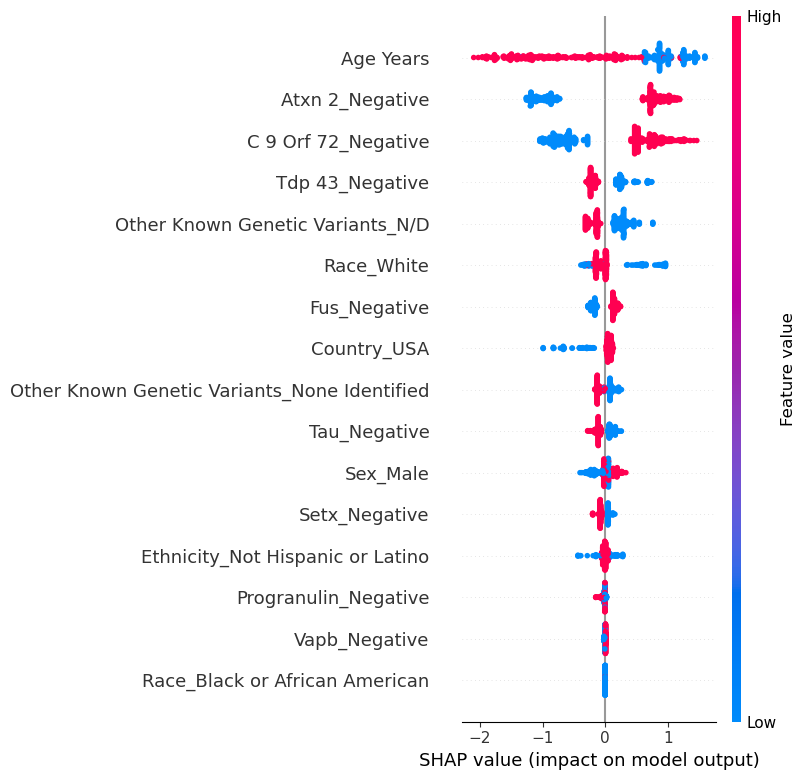

In [21]:
import shap

xgb_model.fit(X[early_fusion_features], y)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X[early_fusion_features])

shap.summary_plot(shap_values, X[early_fusion_features])


In [22]:
shap_df = pd.DataFrame(abs(shap_values), columns=early_fusion_features)

print(shap_df.mean().sort_values(ascending=False).head(15))


Age Years                                       0.961277
Atxn 2_Negative                                 0.919320
C 9 Orf 72_Negative                             0.720996
Tdp 43_Negative                                 0.259123
Other Known Genetic Variants_N/D                0.232279
Race_White                                      0.171733
Fus_Negative                                    0.171062
Country_USA                                     0.116876
Other Known Genetic Variants_None Identified    0.105730
Tau_Negative                                    0.104124
Sex_Male                                        0.100346
Setx_Negative                                   0.068155
Ethnicity_Not Hispanic or Latino                0.042673
Progranulin_Negative                            0.018302
Vapb_Negative                                   0.007252
dtype: float32


In [19]:
X_inter = X.copy()

X_inter["C9_Age_Interaction"] = (
    X["C 9 Orf 72_Negative"] * X["Age Years"]
)

features = [
    "C 9 Orf 72_Negative",
    "Age Years",
    "C9_Age_Interaction"
]

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

interaction_auc = cross_val_score(
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
    X_inter[features],
    y,
    cv=cv,
    scoring="roc_auc"
)

print("C9 × Age Interaction AUC:")
print("Mean:", interaction_auc.mean())
print("Std :", interaction_auc.std())


C9 × Age Interaction AUC:
Mean: 0.8439405439595191
Std : 0.038986248078981676


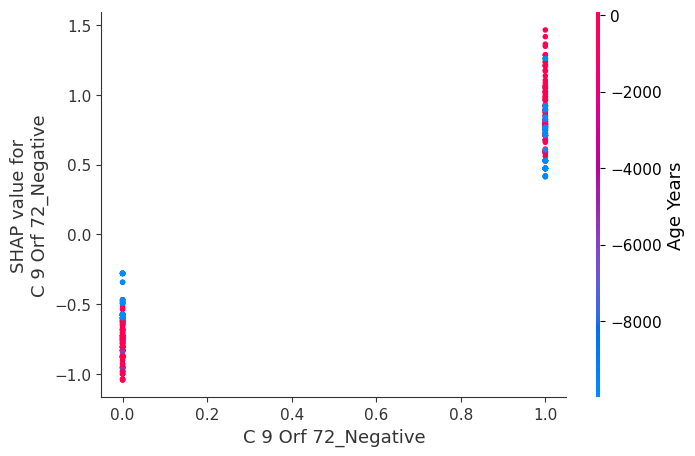

In [20]:
shap.dependence_plot(
    "C 9 Orf 72_Negative",
    shap_values,
    X[early_fusion_features],
    interaction_index="Age Years"
)
